using autoencoder to reconstruct grey scale images of MNIST dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.07MB/s]


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 10

for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images.view(-1, 28*28))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.0609
Epoch [2/10], Loss: 0.0309
Epoch [3/10], Loss: 0.0254
Epoch [4/10], Loss: 0.0221
Epoch [5/10], Loss: 0.0198
Epoch [6/10], Loss: 0.0181
Epoch [7/10], Loss: 0.0168
Epoch [8/10], Loss: 0.0158
Epoch [9/10], Loss: 0.0148
Epoch [10/10], Loss: 0.0139


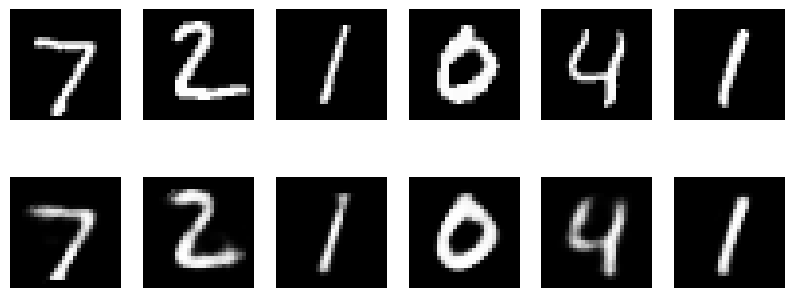

In [ ]:
data_iter = iter(test_loader)
images, _ = next(data_iter)
images = images.to(device)

outputs = model(images)


images = images.cpu()
outputs = outputs.view(-1, 1, 28, 28).detach().cpu()


plt.figure(figsize=(10,4))

for i in range(6):

    plt.subplot(2,6,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')


    plt.subplot(2,6,i+7)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()